In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:

path = "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/results/disease_mapping/TAURUS_raw_counts_annotated_final_annotated.h5ad"
adata = sc.read_h5ad(path)


In [6]:
for celltype in adata.obs['predicted_Prelim_annotation'].unique():
    print(celltype)

Plasma IGA
vascular endothelial Arteriolar
CD4 Th17
CD4 Naive
vascular endothelial Venular
Colonocytes Late
Secretory Goblet Cells
Pericytes Angiogenic
CD4 Treg
CD8 Circulating Effector/Memory
Not predicted
Macrophages Tissue Resident
Colonocytes
Plasma Cells
CD8 T
Plasma IGG
Monocytes
Pericytes Contractile
CD4 Tfh
Pericytes Immature
Fibroblasts Lamina propria (S1)
CD4 Memory
CD8 IEL
DC cDC2
vascular endothelial
vascular endothelial Capillary
Transiently Amplifying Cells (TA)
vascular endothelial Pre venule capillary (PVC)
Smooth Muscle Cells (SMC)
Fibroblasts Crypt Bottom (S2A)
Secretory Tuft Cells
CD8 Effector/Memory
ILC NK Cells
Fibroblasts Muscularis Propria
DC cDC1
Fibroblasts Subserosal
CD4 Th1
Glia Myenteric Plexus / Type I
Fibroblasts Myofibroblasts
CD8 TRM
Fibroblasts Submucosal (aka Crypt Support/Trophocytes/S3)
Colonocytes Early
Fibroblasts Crypt Top (S2B)
doublet
ILC3
Fibroblasts Subepithelial (S2)
Follicle associated enterocyte (FAE)
Cycling TA
CD8 Naive
vascular endotheli

In [19]:
# Setup

col_entropy = "uncertainty_Prelim_annotation"
col_label = "predicted_Prelim_annotation"
col_disease = "Disease"

need = [col_entropy, col_label, col_disease]
missing = [c for c in need if c not in adata.obs.columns]
if missing:
    raise ValueError("Missing obs columns: " + ", ".join(missing))

df = adata.obs[[col_disease, col_label, col_entropy]].copy()
df = df.dropna(subset=[col_disease, col_label, col_entropy])

disease_order = ["Healthy", "CD", "UC"]
df = df[df[col_disease].isin(disease_order)].copy()
df[col_disease] = pd.Categorical(df[col_disease], categories=disease_order, ordered=True)

df = df.rename(columns={col_entropy: "Shannon_Entropy"})

disease_colors = {
    "Healthy": "#12EAEA",
    "CD": "#B0DB43",
    "UC": "#DB2763",
}



In [20]:
def map_label_to_coarse_group(label):
    s = str(label)

    if s in ["Not predicted", "lowQ"]:
        return "QC or Unassigned"
    if s == "doublet":
        return "Doublet"
    if s == "Epithelial":
        return "Other epithelial"

    if "Colonocytes" in s or "Enterocytes" in s or "Absorptive TA" in s or "Follicle associated enterocyte" in s or "FAE" in s:
        return "Absorptive epithelial"
    if "Secretory" in s or "Goblet" in s or "Paneth" in s or "Tuft" in s or "Microfold" in s or "M Cells" in s:
        return "Secretory epithelial"
    if "EEC" in s or "Enteroendocrine" in s:
        return "Enteroendocrine"

    if s.startswith("CD4 "):
        return "CD4 T"
    if s.startswith("CD8 "):
        return "CD8 T"
    if s.startswith("T "):
        return "Other T"

    if "ILC" in s or "NK" in s:
        return "ILC and NK"

    if s.startswith("DC") or "dendritic" in s or "migDC" in s or "cDC" in s or "MO DC" in s:
        return "Dendritic cells"

    if "Macrophage" in s or s.startswith("Macrophages") or s.startswith("Macrophage"):
        return "Macrophages"
    if "Monocyte" in s or s == "Monocytes":
        return "Monocytes"

    if s.startswith("B "):
        return "B cells"
    if "GC B" in s:
        return "B cells"
    if "Plasma" in s:
        return "Plasma cells"

    if "Granulocyte" in s or "Mast" in s:
        return "Granulocytes"

    if "vascular endothelial" in s:
        return "Endothelial"
    if s == "vascular endothelial":
        return "Endothelial"

    if s.startswith("Pericytes") or "Pericytes" in s:
        return "Pericytes"

    if "Smooth Muscle" in s or s.startswith("SMC") or " Muscle Cells" in s:
        return "Smooth muscle"

    if s.startswith("Fibroblasts") or "Fibroblastic" in s or "Myofibroblasts" in s:
        return "Fibroblasts"

    if "Glia" in s:
        return "Glia"

    if "Cycling" in s:
        return "Cycling"

    if "Myeloid" in s:
        return "Other myeloid"

    return "Other"


df["coarse_group"] = df[col_label].map(map_label_to_coarse_group)

group_order = [
    "Absorptive epithelial",
    "Secretory epithelial",
    "Enteroendocrine",
    "Macrophages",
    "Monocytes",
    "Dendritic cells",
    "Other myeloid",
    "Granulocytes",
    "CD4 T",
    "CD8 T",
    "Other T",
    "ILC and NK",
    "B cells",
    "Plasma cells",
    "Endothelial",
    "Pericytes",
    "Smooth muscle",
    "Fibroblasts",
    "Glia",
    "Cycling",
    "QC or Unassigned",
    "Doublet",
    "Other",
]

present_groups = [g for g in group_order if (df["coarse_group"] == g).any()]




/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_54371/307480758.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_54371/307480758.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_54371/307480758.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_54371/307480758.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

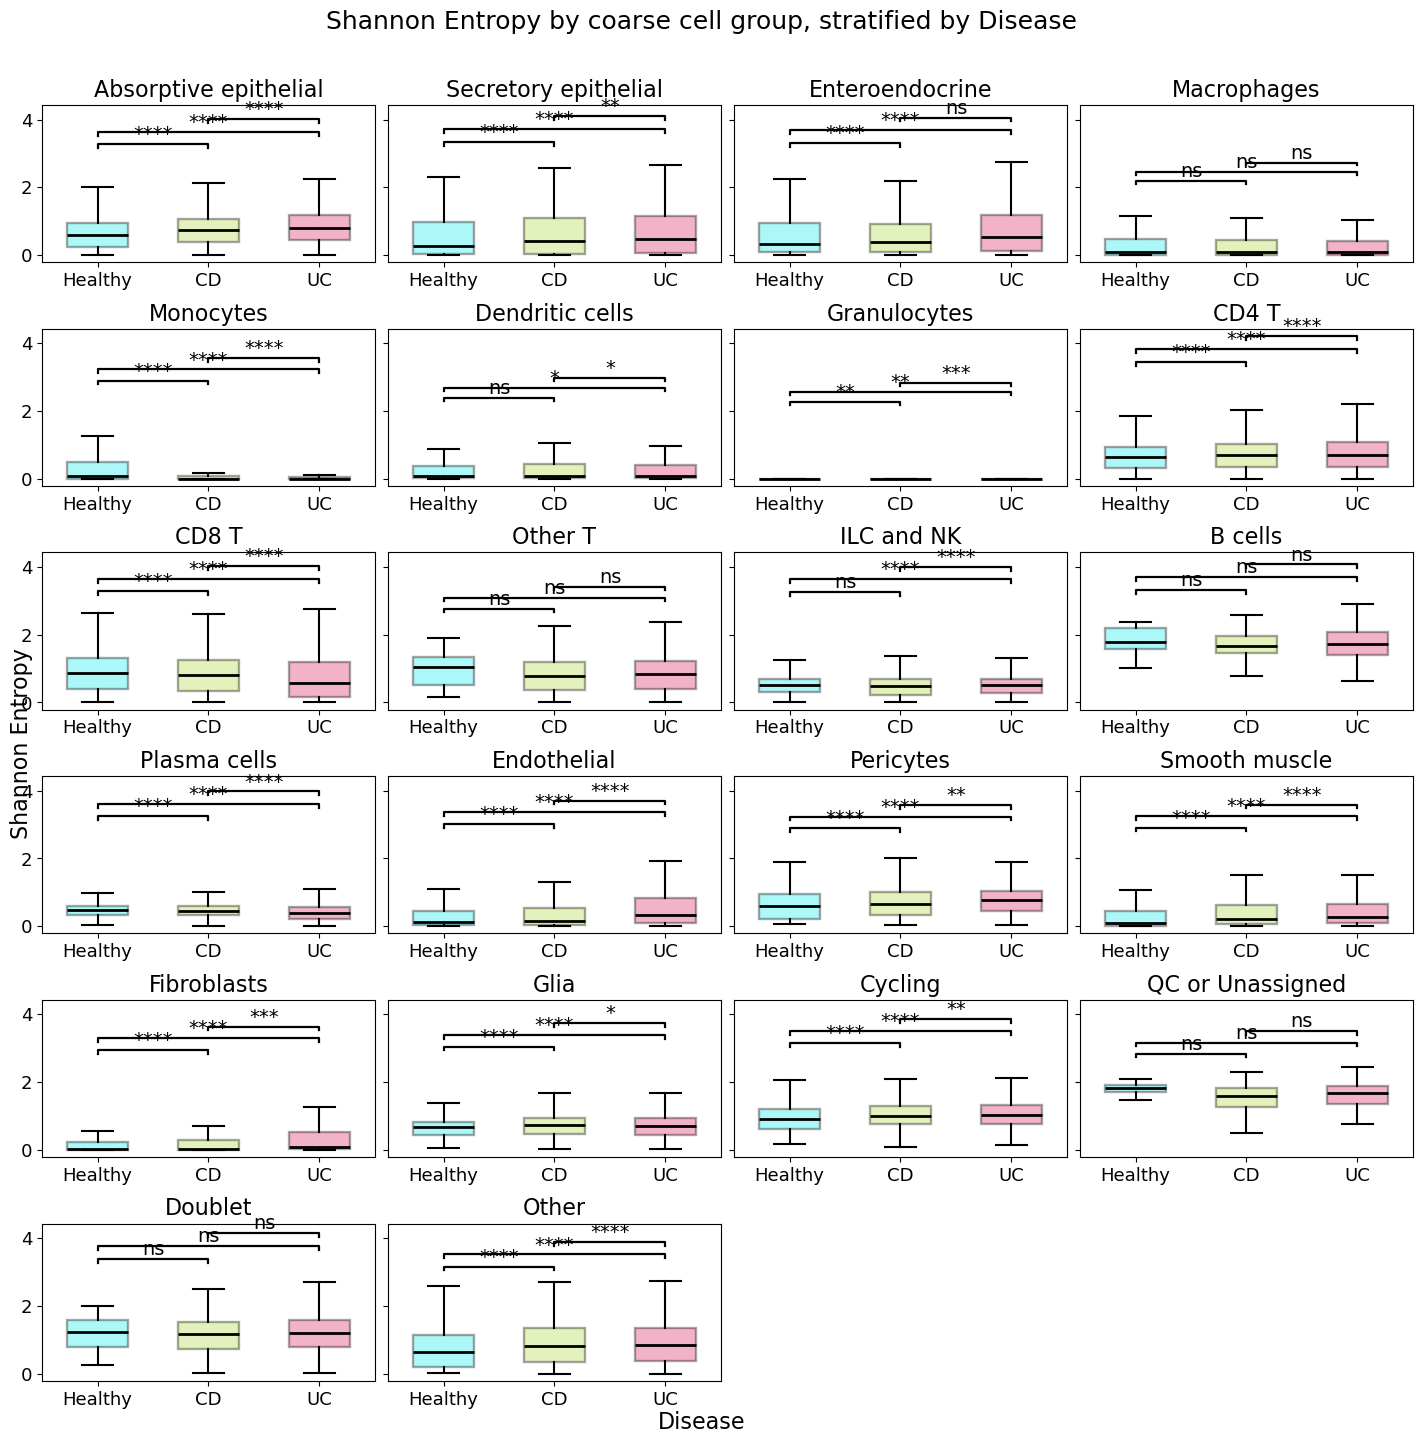

In [21]:
from scipy.stats import mannwhitneyu

def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = np.empty(n, dtype=float)
    ranked[order] = p[order] * n / (np.arange(n) + 1.0)
    q = np.minimum.accumulate(ranked[np.argsort(order)][::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty(n, dtype=float)
    out[order] = q[np.argsort(order)]
    return out

def p_to_stars(p):
    if p <= 1e-4:
        return "****"
    if p <= 1e-3:
        return "***"
    if p <= 1e-2:
        return "**"
    if p <= 5e-2:
        return "*"
    return "ns"

def add_sig(ax, x1, x2, y, h, text, fs=14):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.6, c="black")
    ax.text((x1 + x2) / 2.0, y + h, text, ha="center", va="bottom", fontsize=fs)


def boxplot_facet_by_group_with_stats(
    df_in,
    groups,
    diseases,
    colors,
    y_col="Shannon_Entropy",
    fdr_within_group=True,
    ncols=4,
):
    pair_defs = [(0, 1), (0, 2), (1, 2)]
    n = len(groups)
    nrows = int(np.ceil(n / ncols))

    # Smaller panels, bigger annotation, tighter layout
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.6 * ncols, 2.35 * nrows),
        sharey=True,
    )
    axes = np.array(axes).reshape(nrows, ncols)
    axes_flat = axes.flatten()

    title_fs = 16
    tick_fs = 13
    n_fs = 12
    star_fs = 14
    sup_fs = 18
    label_fs = 16

    for i, g in enumerate(groups):
        ax = axes_flat[i]
        sub = df_in[df_in["coarse_group"] == g]

        data = []
        for d in diseases:
            arr = sub.loc[sub[col_disease] == d, y_col].to_numpy()
            arr = arr[np.isfinite(arr)]
            data.append(arr)

        bp = ax.boxplot(
            data,
            labels=diseases,
            showfliers=False,
            patch_artist=True,
            widths=0.55,
            boxprops=dict(linewidth=1.7, edgecolor="black"),
            whiskerprops=dict(linewidth=1.5, color="black"),
            capprops=dict(linewidth=1.5, color="black"),
            medianprops=dict(linewidth=2.0, color="black"),
        )

        for j, box in enumerate(bp["boxes"]):
            d = diseases[j]
            box.set_facecolor(colors[d])
            box.set_alpha(0.35)
            box.set_edgecolor("black")

        ax.set_title(g, fontsize=title_fs)
        ax.tick_params(axis="x", labelsize=tick_fs)
        ax.tick_params(axis="y", labelsize=tick_fs)

        ns = [len(x) for x in data]
#         ax.text(
#             0.02,
#             0.98,
#             "n " + ", ".join([diseases[k] + " " + str(ns[k]) for k in range(len(diseases))]),
#             transform=ax.transAxes,
#             ha="left",
#             va="top",
#             fontsize=n_fs,
#         )

        pvals = []
        for a, b in pair_defs:
            xa = data[a]
            xb = data[b]
            if (xa.size == 0) or (xb.size == 0):
                p = np.nan
            else:
                p = mannwhitneyu(xa, xb, alternative="two-sided").pvalue
            pvals.append(p)

        p_use = np.array(pvals, dtype=float)
        ok = np.isfinite(p_use)
        if fdr_within_group and ok.sum() > 0:
            p_adj = np.full_like(p_use, np.nan, dtype=float)
            p_adj[ok] = bh_fdr(p_use[ok])
        else:
            p_adj = p_use

        ymax = np.nanmax([np.nanmax(x) if x.size else np.nan for x in data])
        if not np.isfinite(ymax):
            continue

        span = abs(ymax) + 1.0
        y0 = ymax + 0.08 * span
        h = 0.03 * span

        for k, (a, b) in enumerate(pair_defs):
            if not np.isfinite(p_adj[k]):
                lab = "na"
            else:
                lab = p_to_stars(p_adj[k])
            add_sig(ax, a + 1, b + 1, y0 + k * (h * 3.2), h, lab, fs=star_fs)

    for k in range(n, len(axes_flat)):
        axes_flat[k].axis("off")

    fig.suptitle("Shannon Entropy by coarse cell group, stratified by Disease", y=1.02, fontsize=sup_fs)
    fig.supxlabel("Disease", fontsize=label_fs)
    fig.supylabel("Shannon Entropy", fontsize=label_fs)
    fig.tight_layout(pad=0.6, w_pad=0.6, h_pad=0.9)
    plt.show()

boxplot_facet_by_group_with_stats(
    df_in=df,
    groups=present_groups,
    diseases=disease_order,
    colors=disease_colors,
    y_col="Shannon_Entropy",
    fdr_within_group=True,
    ncols=4,
)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_54371/200783921.py:288: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout(pad=0.6, w_pad=0.7, h_pad=1.0)


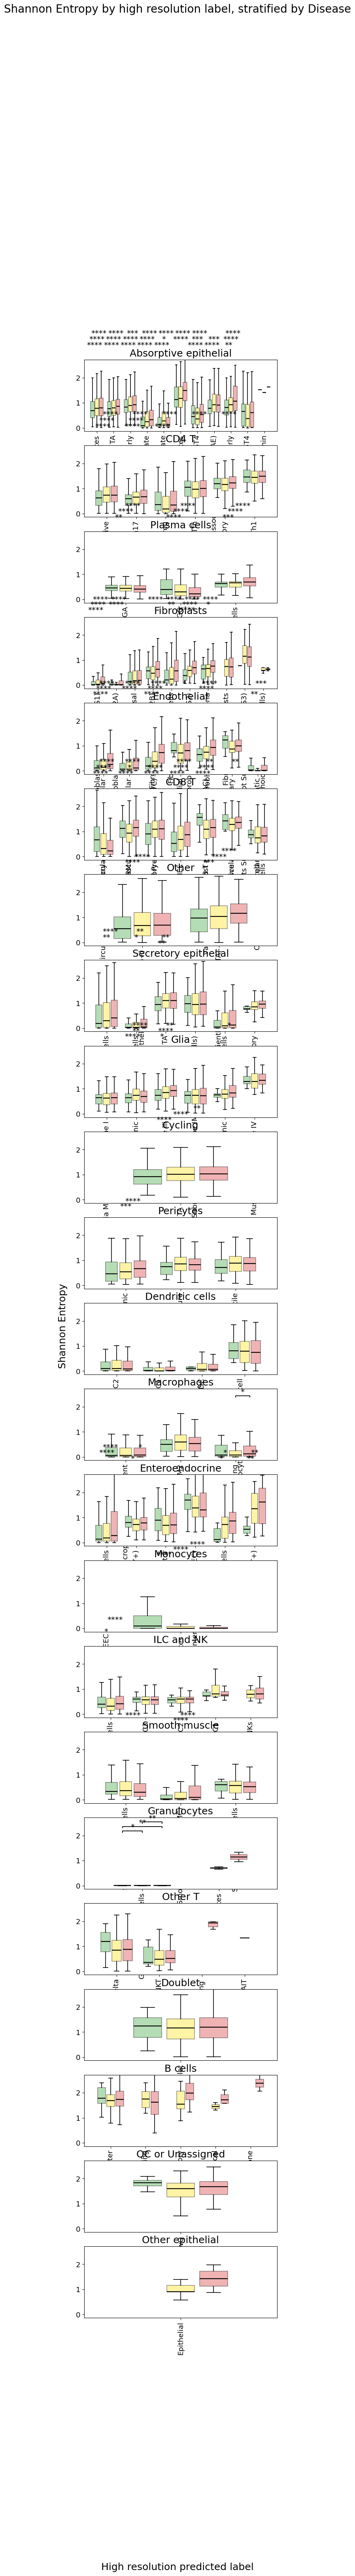

In [18]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

path = "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/results/disease_mapping/TAURUS_raw_counts_annotated_final_annotated.h5ad"
adata = sc.read_h5ad(path)

col_entropy = "uncertainty_Prelim_annotation"
col_label = "predicted_Prelim_annotation"
col_disease = "Disease"

need = [col_entropy, col_label, col_disease]
missing = [c for c in need if c not in adata.obs.columns]
if missing:
    raise ValueError("Missing obs columns: " + ", ".join(missing))

df = adata.obs[[col_disease, col_label, col_entropy]].copy()
df = df.dropna(subset=[col_disease, col_label, col_entropy])
df = df.rename(columns={col_entropy: "Shannon_Entropy"})

disease_order = ["Healthy", "CD", "UC"]
df = df[df[col_disease].isin(disease_order)].copy()
df[col_disease] = pd.Categorical(df[col_disease], categories=disease_order, ordered=True)

disease_colors = {
    "Healthy": "#2ca02c",
    "CD": "#ffdd00",
    "UC": "#d62728",
}

def map_label_to_coarse_group(label):
    s = str(label)

    if s in ["Not predicted", "lowQ"]:
        return "QC or Unassigned"
    if s == "doublet":
        return "Doublet"
    if s == "Epithelial":
        return "Other epithelial"

    if ("Colonocytes" in s) or ("Enterocytes" in s) or ("Absorptive TA" in s) or ("Follicle associated enterocyte" in s) or ("FAE" in s):
        return "Absorptive epithelial"
    if ("Secretory" in s) or ("Goblet" in s) or ("Paneth" in s) or ("Tuft" in s) or ("Microfold" in s) or ("M Cells" in s):
        return "Secretory epithelial"
    if ("EEC" in s) or ("Enteroendocrine" in s):
        return "Enteroendocrine"

    if s.startswith("CD4 "):
        return "CD4 T"
    if s.startswith("CD8 "):
        return "CD8 T"
    if s.startswith("T "):
        return "Other T"

    if ("ILC" in s) or ("NK" in s):
        return "ILC and NK"

    if s.startswith("DC") or ("dendritic" in s) or ("migDC" in s) or ("cDC" in s) or ("MO DC" in s):
        return "Dendritic cells"

    if ("Macrophage" in s) or s.startswith("Macrophages") or s.startswith("Macrophage"):
        return "Macrophages"
    if ("Monocyte" in s) or (s == "Monocytes"):
        return "Monocytes"

    if s.startswith("B ") or ("GC B" in s):
        return "B cells"
    if "Plasma" in s:
        return "Plasma cells"

    if ("Granulocyte" in s) or ("Mast" in s):
        return "Granulocytes"

    if "vascular endothelial" in s:
        return "Endothelial"

    if "Pericytes" in s:
        return "Pericytes"

    if ("Smooth Muscle" in s) or s.startswith("SMC") or (" Muscle Cells" in s):
        return "Smooth muscle"

    if s.startswith("Fibroblasts") or ("Fibroblastic" in s) or ("Myofibroblasts" in s):
        return "Fibroblasts"

    if "Glia" in s:
        return "Glia"

    if "Cycling" in s:
        return "Cycling"

    if "Myeloid" in s:
        return "Other myeloid"

    return "Other"

df["coarse_group"] = df[col_label].map(map_label_to_coarse_group)
df["highres_label"] = df[col_label].astype(str)

def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    p_sorted = p[order]
    q_sorted = p_sorted * n / (np.arange(n) + 1.0)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)
    out = np.empty(n, dtype=float)
    out[order] = q_sorted
    return out

def p_to_stars(p):
    if p <= 1e-4:
        return "****"
    if p <= 1e-3:
        return "***"
    if p <= 1e-2:
        return "**"
    if p <= 5e-2:
        return "*"
    return "ns"

def add_sig(ax, x1, x2, y, h, text, fs=12):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.3, c="black")
    ax.text((x1 + x2) / 2.0, y + h, text, ha="center", va="bottom", fontsize=fs)

def grouped_boxplot_one_axis(ax, sub, labels, diseases, colors, y_col, tick_fs, title_fs, n_fs, star_fs):
    offsets = [-0.26, 0.0, 0.26]
    widths = 0.22
    positions = []
    box_data = []
    box_face = []
    box_edge = []

    for i, lab in enumerate(labels):
        for j, dis in enumerate(diseases):
            arr = sub.loc[(sub["highres_label"] == lab) & (sub[col_disease] == dis), y_col].to_numpy()
            arr = arr[np.isfinite(arr)]
            positions.append(i + 1 + offsets[j])
            box_data.append(arr)
            box_face.append(colors[dis])
            box_edge.append("black")

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=widths,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(linewidth=1.4, edgecolor="black"),
        whiskerprops=dict(linewidth=1.2, color="black"),
        capprops=dict(linewidth=1.2, color="black"),
        medianprops=dict(linewidth=1.6, color="black"),
    )
    for k, b in enumerate(bp["boxes"]):
        b.set_facecolor(box_face[k])
        b.set_alpha(0.35)
        b.set_edgecolor("black")

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=90, fontsize=tick_fs)
    ax.tick_params(axis="y", labelsize=tick_fs)

    ymax = np.nanmax(sub[y_col].to_numpy())
    if np.isfinite(ymax):
        ax.set_ylim(top=ymax + 0.25 * (abs(ymax) + 1.0))

    # Stats: per high-res label, pairwise MWU across diseases (BH within facet)
    pair_defs = [(0, 1), (0, 2), (1, 2)]
    all_p = []
    all_meta = []
    for i, lab in enumerate(labels):
        data = []
        for dis in diseases:
            arr = sub.loc[(sub["highres_label"] == lab) & (sub[col_disease] == dis), y_col].to_numpy()
            arr = arr[np.isfinite(arr)]
            data.append(arr)

        for pidx, (a, b) in enumerate(pair_defs):
            xa = data[a]
            xb = data[b]
            if (xa.size == 0) or (xb.size == 0):
                p = np.nan
            else:
                p = mannwhitneyu(xa, xb, alternative="two-sided").pvalue
            all_p.append(p)
            all_meta.append((i, pidx))

    p_use = np.array(all_p, dtype=float)
    ok = np.isfinite(p_use)
    p_adj = np.full_like(p_use, np.nan, dtype=float)
    if ok.sum() > 0:
        p_adj[ok] = bh_fdr(p_use[ok])

    # Draw bars above each label's 3 boxes
    span = abs(ymax) + 1.0 if np.isfinite(ymax) else 1.0
    base = ymax + 0.06 * span if np.isfinite(ymax) else 0.0
    h = 0.02 * span
    step = 0.06 * span

    for idx, (lab_i, pidx) in enumerate(all_meta):
        if not np.isfinite(p_adj[idx]):
            continue
        stars = p_to_stars(p_adj[idx])
        if stars == "ns":
            continue

        center = lab_i + 1
        x_positions = [center + offsets[0], center + offsets[1], center + offsets[2]]
        if pidx == 0:
            x1, x2 = x_positions[0], x_positions[1]
            y = base + 0 * step
        elif pidx == 1:
            x1, x2 = x_positions[0], x_positions[2]
            y = base + 1 * step
        else:
            x1, x2 = x_positions[1], x_positions[2]
            y = base + 2 * step

        add_sig(ax, x1, x2, y, h, stars, fs=star_fs)

def plot_faceted_highres(
    df_in,
    diseases,
    colors,
    y_col="Shannon_Entropy",
    ncols=1,
    max_labels_per_facet=18,
):
    # Choose top labels per coarse group so the x axis doesnt explode
    tmp = df_in.copy()
    counts = tmp.groupby(["coarse_group", "highres_label"]).size().reset_index(name="n")

    facet_groups = counts.groupby("coarse_group")["n"].sum().sort_values(ascending=False).index.tolist()

    facets = []
    for g in facet_groups:
        labs = (
            counts[counts["coarse_group"] == g]
            .sort_values("n", ascending=False)
            .head(max_labels_per_facet)["highres_label"]
            .tolist()
        )
        if len(labs) > 0:
            facets.append((g, labs))

    n = len(facets)
    nrows = int(np.ceil(n / ncols))

    # Smaller plot area, bigger text
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.3 * ncols, 2.8 * nrows), sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)
    axes_flat = axes.flatten()

    title_fs = 18
    tick_fs = 13
    star_fs = 14
    sup_fs = 20
    label_fs = 18

    for i, (g, labs) in enumerate(facets):
        ax = axes_flat[i]
        sub = df_in[df_in["coarse_group"] == g].copy()
        sub = sub[sub["highres_label"].isin(labs)].copy()

        grouped_boxplot_one_axis(
            ax=ax,
            sub=sub,
            labels=labs,
            diseases=diseases,
            colors=colors,
            y_col=y_col,
            tick_fs=tick_fs,
            title_fs=title_fs,
            n_fs=12,
            star_fs=star_fs,
        )
        ax.set_title(g, fontsize=title_fs)

    for k in range(n, len(axes_flat)):
        axes_flat[k].axis("off")

    fig.suptitle("Shannon Entropy by high resolution label, stratified by Disease", y=1.02, fontsize=sup_fs)
    fig.supxlabel("High resolution predicted label", fontsize=label_fs)
    fig.supylabel("Shannon Entropy", fontsize=label_fs)
    fig.tight_layout(pad=0.6, w_pad=0.7, h_pad=1.0)
    plt.show()

plot_faceted_highres(
    df_in=df,
    diseases=disease_order,
    colors=disease_colors,
    y_col="Shannon_Entropy",
    ncols=1,
    max_labels_per_facet=18,
)
